In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    MeanShift,
    estimate_bandwidth,
    AgglomerativeClustering,
)
from sklearn_extra.cluster import KMedoids
from sklearn.mixture import GaussianMixture

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from scipy.cluster.hierarchy import dendrogram

from Transformers import *  


In [4]:
df=pd.read_csv("data/CleanedKaggle/financial_loan_cleaned.csv") 

preprocessing danych

In [5]:
preprocessor = getPipeline()
np_preprocessed = preprocessor.fit_transform(df)
np_preprocessed.shape

(38576, 33)

In [6]:
df_preprocessed = pd.DataFrame(np_preprocessed, columns=preprocessor.get_feature_names_out(df.columns.tolist()))
# usuwamy basic_cat__loan_status_Fully Paid i ct_onehot__job__title_categorized_Other z uwagi na wysoką korelację z innymi zmiennymi, gdzie ta korelacja
# wynika ze wspólnego źródła danych (jakiegoś faktu) dla tych zmiennych
df_preprocessed.drop(columns=['basic_cat__loan_status_Fully Paid', 'ct_onehot__job__title_categorized_Other'], inplace=True)

In [13]:
X=df_preprocessed

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold      import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def tsne_plot(
    X,
    y=None,                  
    perplexity=30,
    learning_rate=200,
    n_iter=1000,            
    pca_dim=None,
    random_state=42,
    figsize=(6, 5),
    cmap="tab10",            
):
    
    
    X_proc = StandardScaler().fit_transform(X)

   
    if pca_dim is not None and X_proc.shape[1] > pca_dim:
        X_proc = PCA(n_components=pca_dim, random_state=random_state)\
                 .fit_transform(X_proc)

    
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        n_iter=n_iter,
        init="random",
        random_state=random_state,
    )
    embedding = tsne.fit_transform(X_proc)

   
    plt.figure(figsize=figsize)

    if y is None:
        
        plt.scatter(embedding[:, 0], embedding[:, 1],
                    s=20, alpha=0.7, edgecolors="k", linewidths=0.3)
    else:
        
        y = np.asarray(y)
        n_classes = len(np.unique(y))
        cmap_mod  = plt.cm.get_cmap(cmap, n_classes)  

        scatter = plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=y,
            cmap=cmap_mod,
            s=20,
            alpha=0.8,
            edgecolors="k",
            linewidths=0.3,
        )
        handles, labels = scatter.legend_elements(prop="colors", alpha=0.8)
        plt.legend(handles, labels, title="cluster", loc="best", frameon=False)

    plt.title("t-SNE projection")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return embedding


/Users/piotrkot/Programming/PycharmProjects/UNI/UczenieMaszynowe/.venv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


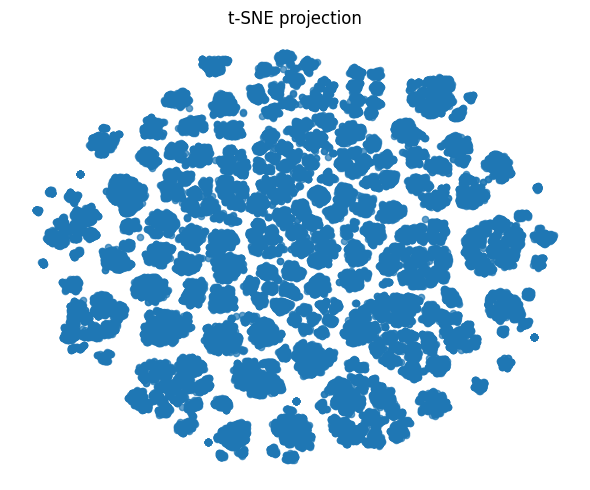

array([[ 35.958977,  11.17174 ],
       [ -9.056833,  65.14747 ],
       [  5.227085,  33.123478],
       ...,
       [-76.5386  ,  16.849934],
       [-63.880688,  12.641262],
       [-64.569786,   9.949482]], dtype=float32)

In [71]:
#tsne_plot(X)

## AgglomerativeClustering

In [65]:

def agglomerative_quality_plot(
    X,
    n_clusters_range=range(2, 11),
    linkage="ward",
    metric="euclidean",
    compute_metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
):
    
    results = {m: [] for m in compute_metrics}

    print(f"{'k':^3s} | {'clusters':^8s}" +
          "".join([f" | {m.replace('_',' ').title():^18s}" for m in compute_metrics]))
    print("-" * (12 + 22 * len(compute_metrics)))

    for k in n_clusters_range:
        
        kwargs = dict(n_clusters=k, linkage=linkage)
        
        if linkage != "ward":
            kwargs["metric"] = metric

        model = AgglomerativeClustering(**kwargs)
        labels = model.fit_predict(X)

        
        for m in compute_metrics:
            if len(np.unique(labels)) <= 1:
                val = 0.0
            elif m == "silhouette":
                val = silhouette_score(X, labels, metric=metric)
            elif m == "davies_bouldin":
                val = davies_bouldin_score(X, labels)
            elif m == "calinski_harabasz":
                val = calinski_harabasz_score(X, labels)
            else:
                raise ValueError(f"Nieznana metryka: {m}")
            results[m].append(val)

        
        row = f"{k:^3d} | {len(np.unique(labels)):8d}" + \
              "".join([f" | {results[m][-1]:18.4f}" for m in compute_metrics])
        print(row)

    
    colors = {"silhouette": "tab:blue",
              "davies_bouldin": "tab:red",
              "calinski_harabasz": "tab:green"}

    n_rows = len(compute_metrics)
    fig, axes = plt.subplots(n_rows, 1, figsize=(8, 3 * n_rows), sharex=True)

    if n_rows == 1:
        axes = [axes]

    for ax, m in zip(axes, compute_metrics):
        ax.plot(
            list(n_clusters_range),
            results[m],
            marker="o",
            color=colors.get(m, "black"),
            label=m.replace("_", " ").title(),
        )
        ax.set_ylabel(m.replace("_", " ").title())
        ax.grid(alpha=0.4)
        ax.legend()

    axes[-1].set_xlabel("Liczba klastrów (k)")
    plt.suptitle(
        f"Agglomerative ({linkage}, metric={metric}) – jakościowe metryki vs. liczba klastrów",
        y=0.93,
        fontsize=14,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


 k  | clusters |     Silhouette     |   Davies Bouldin   | Calinski Harabasz 
------------------------------------------------------------------------------
 2  |        2 |             0.1914 |             2.0451 |          4715.0978


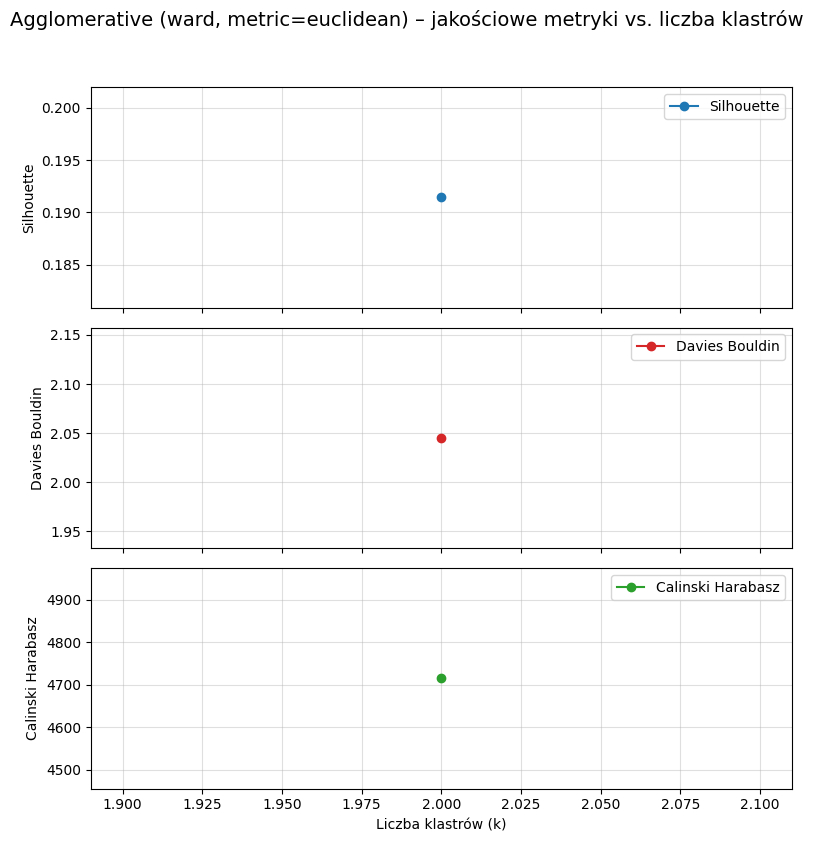

In [66]:
agglomerative_quality_plot(X,n_clusters_range=range(2,3))

## Kmeans

In [24]:
def KMeans_plotter(X, lower_bound=2, upper_bound=20):
    if lower_bound < 2:
        raise ValueError("lower_bound must be at least 2.")
    
    inertia_list = []
    silhouette_list = []
    

    for i in range(lower_bound, upper_bound + 1):
        k = KMeans(n_clusters=i, random_state=42)
        k.fit(X)
        predicted = k.predict(X)
        inertia_list.append(k.inertia_)
        silhouette_list.append(silhouette_score(X, predicted))
    
    x_cord = np.arange(lower_bound, upper_bound + 1)
    
    
    
    fig, ax1 = plt.subplots(figsize=(8, 5))



    ax1.plot(x_cord, inertia_list, color='blue', linewidth=2, label='Inertia ')

    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.5)


    ax2 = ax1.twinx()

    ax2.plot(x_cord, silhouette_list, color='orange', linewidth=2, label='Silhouette ')

    ax2.set_ylabel('Silhouette Score', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')


    legend1 = ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
    for text in legend1.get_texts():
        text.set_color('blue')

    legend2 = ax2.legend(loc='upper right', bbox_to_anchor=(1.0, 0.92))
    for text in legend2.get_texts():
        text.set_color('orange')

    plt.title('Inertia and Silhouette Scores vs. Number of Clusters')
    plt.tight_layout()


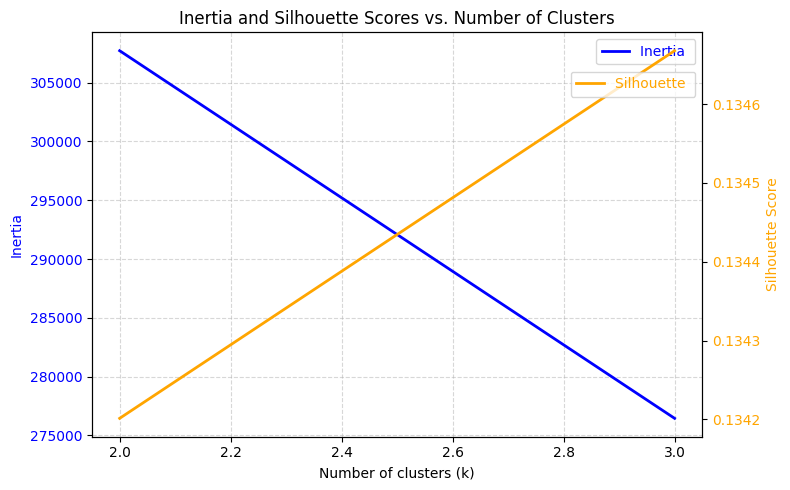

In [25]:
KMeans_plotter(X,2,3)

## Kmedoids

In [ ]:
def KMedoids_plotter(X, lower_bound=2, upper_bound=20, metric='euclidean'):
    
    if lower_bound < 2:
        raise ValueError("lower_bound must be at least 2.")
    
    inertia_list = []
    silhouette_list = []

    
    for k in range(lower_bound, upper_bound + 1):
        
        kmedoids = KMedoids(
            n_clusters=k,
            metric=metric,
            random_state=42,
            method='pam'     
        )
        labels = kmedoids.fit_predict(X)

        
        inertia_list.append(kmedoids.inertia_)

        
        unique_labels = np.unique(labels)
        if len(unique_labels) > 1:
            sil = silhouette_score(X, labels, metric=metric)
        else:
            sil = 0.0
        silhouette_list.append(sil)

    x_cord = np.arange(lower_bound, upper_bound + 1)

   
    fig, ax1 = plt.subplots(figsize=(8, 5))

    
    ax1.plot(
        x_cord,
        inertia_list,
        color='blue',
        linewidth=2,
        marker='o',
        label='Inertia'
    )
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.5)

    
    ax2 = ax1.twinx()
    ax2.plot(
        x_cord,
        silhouette_list,
        color='orange',
        linewidth=2,
        marker='s',
        label='Silhouette'
    )
    ax2.set_ylabel('Silhouette Score', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    legend1 = ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
    for text in legend1.get_texts():
        text.set_color('blue')
    legend2 = ax2.legend(loc='upper right', bbox_to_anchor=(1.0, 0.92))
    for text in legend2.get_texts():
        text.set_color('orange')

    plt.title('Inertia and Silhouette Scores vs. Number of Clusters (KMedoids)')
    plt.tight_layout()
    plt.show()


## DB SCAN 

In [74]:
def DBScanner(X, params_list):


    if len(params_list) == 0:
        raise ValueError("Wow!")

    silhouette_list = []
    db_index_list = []
    ch_score_list = []

    
    for i, param in enumerate(params_list):
        db = DBSCAN(**param)
        labels = db.fit_predict(X)

        
        unique_labels = set(labels)
        if len(unique_labels - {-1}) <= 1:
            print(f"param_nr_{i}: Outliers or only one cluster → metryki = 0")
            silhouette_list.append(0.0)
            db_index_list.append(0.0)
            ch_score_list.append(0.0)
        else:
           
            try:
                sil = silhouette_score(X, labels)
            except:
                sil = 0.0

            
            try:
                dbi = davies_bouldin_score(X, labels)
            except:
                dbi = 0.0

            
            try:
                chs = calinski_harabasz_score(X, labels)
            except:
                chs = 0.0

            print(f"param_nr_{i}: Silhouette = {sil:.4f}, "
                  f"Davies–Bouldin = {dbi:.4f}, "
                  f"Calinski–Harabasz = {chs:.4f}")

            silhouette_list.append(sil)
            db_index_list.append(dbi)
            ch_score_list.append(chs)


    param_labels = [f"param_nr_{i}" for i in range(len(params_list))]
    x_pos = np.arange(len(params_list))

    
    fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

  
    axs[0].scatter(x=x_pos, y=silhouette_list, color='tab:blue', edgecolor='k', alpha=0.7)
    axs[0].plot(x_pos, silhouette_list, color='tab:blue', linewidth=2)
    axs[0].set_ylabel('Silhouette Score', color='tab:blue')
    axs[0].tick_params(axis='y', labelcolor='tab:blue')
    axs[0].grid(alpha=0.3)

    
    axs[1].scatter(x=x_pos, y=db_index_list, color='tab:red', edgecolor='k', alpha=0.7)
    axs[1].plot(x_pos, db_index_list, color='tab:red', linewidth=2)
    axs[1].set_ylabel('Davies–Bouldin Index', color='tab:red')
    axs[1].tick_params(axis='y', labelcolor='tab:red')
    axs[1].grid(alpha=0.3)

   
    axs[2].scatter(x=x_pos, y=ch_score_list, color='tab:green', edgecolor='k', alpha=0.7)
    axs[2].plot(x_pos, ch_score_list, color='tab:green', linewidth=2)
    axs[2].set_ylabel('Calinski–Harabasz Score', color='tab:green')
    axs[2].tick_params(axis='y', labelcolor='tab:green')
    axs[2].grid(alpha=0.3)
    axs[2].set_xlabel('Parameter set index')

   
    plt.xticks(ticks=x_pos, labels=param_labels, rotation=45)


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [33]:
params_list = [
    {"eps": 1, "min_samples": 5},
    {"eps": 2, "min_samples": 10},
    {"eps": 3, "min_samples": 5}, 
    {"eps":4,"min_samples": 10},
    {"eps":5,"min_samples":15}
]

param_nr_0: Silhouette = -0.4074, Davies–Bouldin = 1.8333, Calinski–Harabasz = 12.4691
param_nr_1: Outliers or only one cluster → metryki = 0


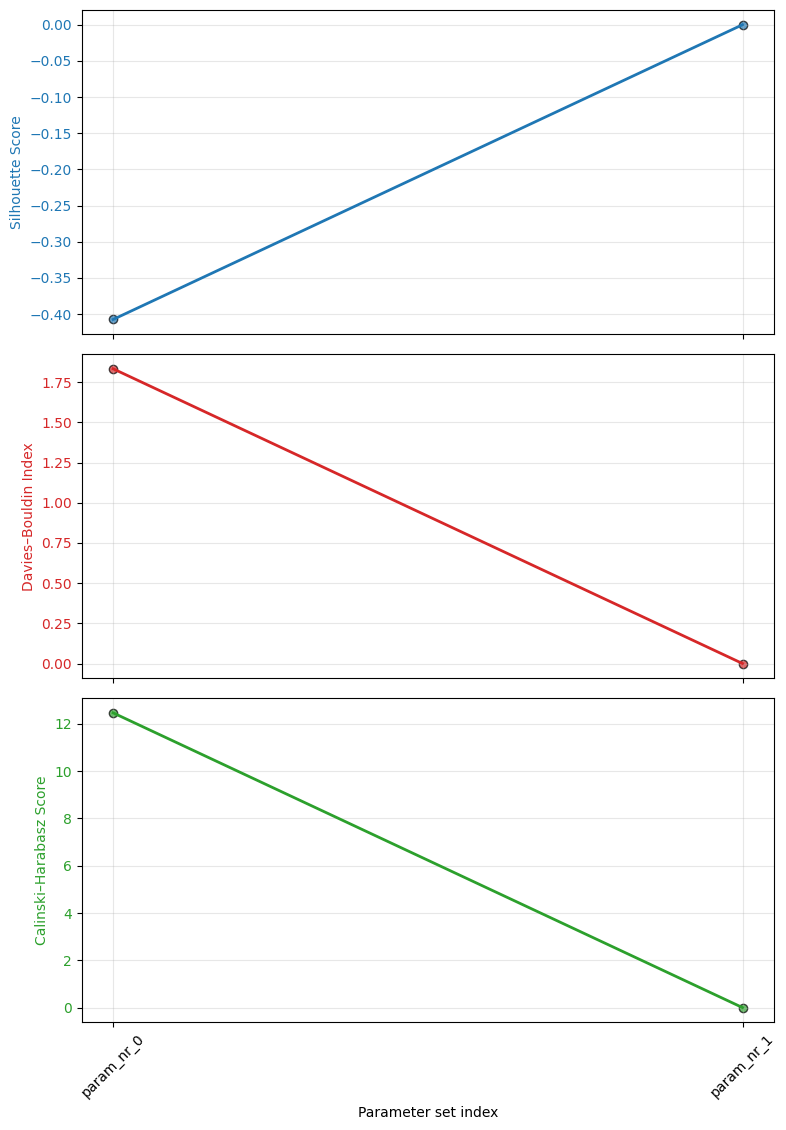

In [34]:
DBScanner(X, params_list)

## Gaussian Mixture Models 

In [53]:

def gmm_optimal_components(
    X,
    min_components=1,
    max_components=10,
    criterion='bic',
    random_state=42
):
   
    n_components_range = np.arange(min_components, max_components + 1)
    aic_values = []
    bic_values = []




    for n in n_components_range:
        
        gmm = GaussianMixture(n_components=n, random_state=random_state)
        gmm.fit(X)

     
        aic = gmm.aic(X)
        bic = gmm.bic(X)
        aic_values.append(aic)
        bic_values.append(bic)


    
    plt.figure(figsize=(8, 5))

    plt.plot(n_components_range, aic_values, marker='o', color='steelblue', label='AIC')
    plt.plot(n_components_range, bic_values, marker='s', color='salmon', label='BIC')


    plt.xticks(n_components_range)
    plt.xlabel('Liczba komponentów (n_components)')
    title = "Kryteria AIC i BIC vs. liczba komponentów (GMM)"
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

   
    if criterion.lower() == 'aic':
        best_idx = np.argmin(aic_values)
        best_n = n_components_range[best_idx]
    elif criterion.lower() == 'bic':
        best_idx = np.argmin(bic_values)
        best_n = n_components_range[best_idx]
    else:
        raise ValueError("Kryterium musi być 'aic' lub 'bic'")

    print(f"\nOptimal {criterion.upper()}: {best_n}")
    return best_n

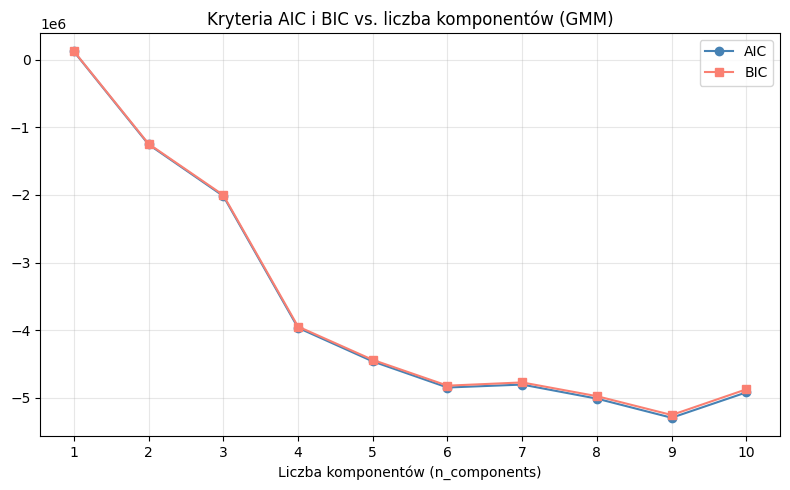


Optimal BIC: 9


9

In [54]:
gmm_optimal_components(X,min_components=1,max_components=10)

## Mean shift 

In [73]:


def meanshift_quality_plot(
    X,
    bandwidth_list,
    metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
    cluster_all=True,
    n_jobs=None,
):
    
    results = {m: [] for m in metrics}
    n_clusters_list = []

    for bw in bandwidth_list:
        ms = MeanShift(bandwidth=bw, cluster_all=cluster_all, n_jobs=n_jobs)
        labels = ms.fit_predict(X)
        n_clusters = len(np.unique(labels))
        n_clusters_list.append(n_clusters)

        if n_clusters <= 1:
            for m in metrics:
                results[m].append(0.0)
            continue

        if "silhouette" in metrics:
            results["silhouette"].append(silhouette_score(X, labels))
        if "davies_bouldin" in metrics:
            results["davies_bouldin"].append(davies_bouldin_score(X, labels))
        if "calinski_harabasz" in metrics:
            results["calinski_harabasz"].append(
                calinski_harabasz_score(X, labels))

  
    n_metrics = len(metrics)
    fig, axs = plt.subplots(
        n_metrics, 1, figsize=(8, 3 * n_metrics), sharex=True
    )

    if n_metrics == 1:
        axs = [axs]  

    colors = {
        "silhouette": "tab:blue",
        "davies_bouldin": "tab:red",
        "calinski_harabasz": "tab:green",
    }
    for ax, m in zip(axs, metrics):
        ax.plot(
            bandwidth_list,
            results[m],
            marker="o",
            color=colors.get(m, "black"),
            label=m.replace("_", " ").title(),
        )
        ax.set_ylabel(m.replace("_", " ").title())
        ax.grid(alpha=0.4)
        ax.legend()

    axs[-1].set_xlabel("Bandwidth")
    plt.suptitle("Miary jakości klasteryzacji vs. bandwidth", y=0.94)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    header = "bandwidth | n_clusters " + " ".join(f"| {m:^18s}" for m in metrics)
    print(header)
    print("-" * len(header))
    for i, bw in enumerate(bandwidth_list):
        row = f"{bw:9.3f} | {n_clusters_list[i]:10d} "
        for m in metrics:
            row += f"| {results[m][i]:18.4f} "
        print(row)


In [61]:
bw_est = estimate_bandwidth(X, quantile=0.2, n_samples=300)
bw_values = np.linspace(bw_est * 0.5, bw_est * 1.5, 8)

meanshift_quality_plot(
        X,
        bandwidth_list=bw_values,
        metrics=("silhouette", "davies_bouldin", "calinski_harabasz"),
    )

KeyboardInterrupt: 